## Import External Packages

In [1]:
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt

## Import Tender Analysis Packages

In [2]:
from src import (
    SifFile,
    find_sif_files,
    compute_background,
    extract_signal,
    CurvatureCorrection,
    OnePot,
    OnePotRIXS
)

## Set Data Directory

In [3]:
# Na2SO4 example data set
DATA = '/sdf/group/ssrl/dsokaras/bl6-2a/tender_data/twopot/data/Na2SO4/*.sif'
files = find_sif_files(DATA)

print(f'{len(files)} *.sif files found in {DATA[:-5]}:\n {files[0][56:]}, {files[1][56:]}... \n ... {files[-1][56:]}')

84 *.sif files found in /sdf/group/ssrl/dsokaras/bl6-2a/tender_data/twopot/data/Na2SO4/:
 Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_2465.00.sif, Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_2467.00.sif... 
 ... Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_dark.sif


## 1. Reading a SIF file

`SifFile` wraps `sif_parser` for the image data and parses the acquisition
comment for additional parameters (e.g. `I0` / `I1` / `mono`).

In [4]:
sif = SifFile(files[30])

### A. Metadata
Various metadata is available from the file comment including:
- X-ray parameters: `I0`, `I1`, `mono`,
- CCD parameters: `exptime`, `numkins`
- Motor positions: `vert`,`Sx`, `Sy`

In [5]:
sif_dict = {
 "I0" : sif.I0,
 "I1" : sif.I1,
 "exposure time" : sif.exposure_time,
 "mono" : sif.mono,
 "num_frames" : sif.num_frames,
 "shape" : sif.shape,
 "metadata" : sif.metadata,
 "info" : sif.info
 }
sif_dict

{'I0': 8972.0,
 'I1': 57.0,
 'exposure time': 1.0,
 'mono': 2482.8,
 'num_frames': 1,
 'shape': (512, 2048),
 'metadata': {'mono': 2482.8,
  'I0': 8972.0,
  'I1': 57.0,
  'exptime': 1.0,
  'numkins': nan,
  'vert': 42.6981},
 'info': OrderedDict([('SifVersion', 65567),
              ('ExperimentTime', 1252658467),
              ('DetectorTemperature', -52.0),
              ('ExposureTime', 1.0),
              ('CycleTime', 2.577),
              ('AccumulatedCycleTime', 2.577),
              ('AccumulatedCycles', 1),
              ('StackCycleTime', 2.577),
              ('PixelReadoutTime', 1e-06),
              ('GainDAC', 0.0),
              ('GateWidth', 0.0),
              ('GratingBlaze', 1.6e-05),
              ('DetectorType', 'DV436'),
              ('DetectorDimensions', (2048, 2048)),
              ('OriginalFilename', b'Acquisition'),
              ('ShutterTime', (0.01, 0.0)),
              ('spectrograph', '999'),
              ('GateGain', 0.0),
              ('GateDelay'

### B. Raw Image and Spectrum
Frames can be accessed via indices using the `frame` method.   

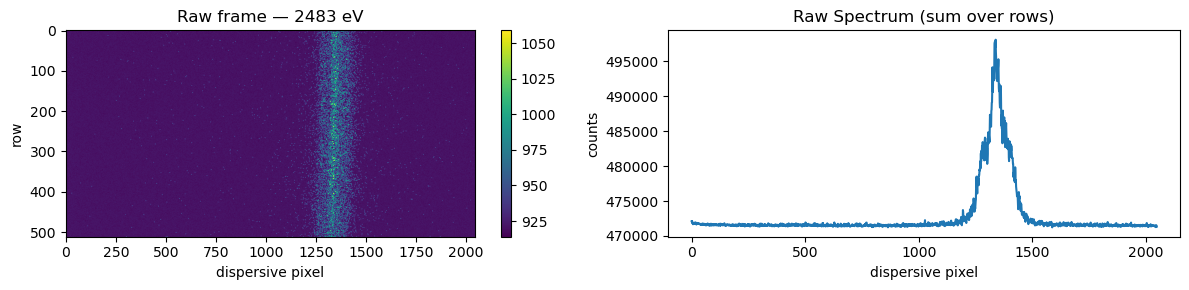

In [6]:
frame = sif.frame(0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
im = ax[0].imshow(frame, aspect='auto', vmin=np.percentile(frame, 1), vmax=np.percentile(frame, 99.5))
ax[0].set(title=f'Raw frame — {sif.mono:.0f} eV', xlabel='dispersive pixel', ylabel='row')
fig.colorbar(im, ax=ax[0])
ax[1].plot(frame.sum(axis=0))
ax[1].set(title='Raw Spectrum (sum over rows)', xlabel='dispersive pixel', ylabel='counts')
plt.tight_layout()

## 2. `OnePot` - XES Pipeline

`OnePot` ties the analysis stages together:   
Resolve files → background → extract → curvature-correct.   
**Note:** `bcg=None` computes the background from the data.

In this example we will analyze Mo VtC on \[CpMo(CO)3\]2 dimer. 

### A. Loading .sif files

In [31]:
# Dimolybdenum samples example data set rXES at 2524.20 eV
DATA2 = '/sdf/group/ssrl/dsokaras/bl6-2a/tender_data/twopot/data/CPMoITriCO3Dimer/*MoL3val_2524*.sif'
files2 = find_sif_files(DATA2)

print(f'{len(files2)} *.sif files found in {DATA2[:-5]}:\n {files2[0][56:]}, {files2[1][56:]}... \n ... {files2[-1][56:]}')

2 *.sif files found in /sdf/group/ssrl/dsokaras/bl6-2a/tender_data/twopot/data/CPMoITriCO3Dimer/*MoL3val_2524:
 CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2524.20eV_01.sif, CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2524.20eV_01_dark.sif... 
 ... CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2524.20eV_01_dark.sif


### B. `OnePot` Analysis

In [32]:
op = OnePot(files2, bcg=None, histograms=True, threshold=[100, 170, 350])
xes = op.run()
spec = xes.spectrum()

Text(0, 0.5, 'Counts')

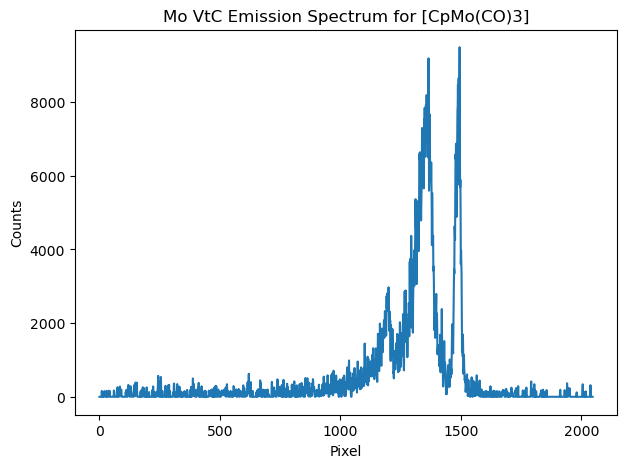

In [33]:
plt.figure(figsize=(7,5))

plt.plot(spec)
plt.title("Mo VtC Emission Spectrum for [CpMo(CO)3]")
plt.xlabel("Pixel")
plt.ylabel("Counts")

### C. Diagnostic histograms - Determining ADU thresholds

In [34]:
H = xes.histograms
th = op.thresholds

print('Thresholds [bcg_cutoff, low, xray, hi] =', th.as_array())

Thresholds [bcg_cutoff, low, xray, hi] = [100. 170. 187. 350.]


X-ray event peak at ADU = 247


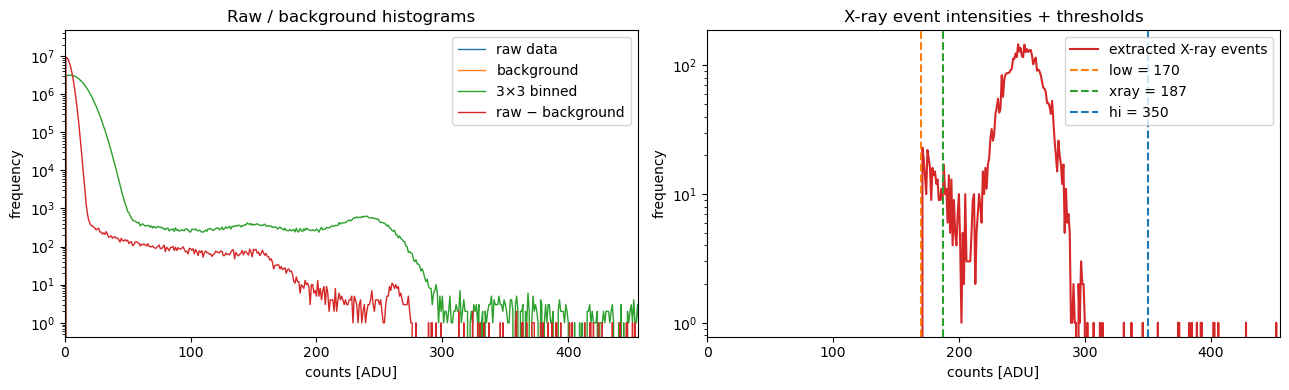

In [35]:
adu = np.arange(H['raw'].size)
fig, ax = plt.subplots(1, 2, figsize=(13,4))

# left: raw / background / binned — the "noise" side, log scale
for key, lbl in [('raw', 'raw data'), ('background', 'background'),
                 ('binned', '3×3 binned'), ('bkg_free', 'raw − background')]:
    ax[0].semilogy(adu, H[key], label=lbl, lw=1)
ax[0].set(title='Raw / background histograms', xlabel='counts [ADU]',
          ylabel='frequency', xlim=(0, 1.3 * th.hi))
ax[0].legend()

# right: extracted X-ray events with threshold markers
ax[1].semilogy(adu, H['xray'], color='C3', label='extracted X-ray events')
for val, name, c in [(th.low, 'low', 'C1'), (th.xray, 'xray', 'C2'), (th.hi, 'hi', 'C0')]:
    ax[1].axvline(val, ls='--', color=c, label=f'{name} = {val:.0f}')
ax[1].set(title='X-ray event intensities + thresholds', xlabel='counts [ADU]',
          ylabel='frequency', xlim=(0, 1.3 * th.hi))
ax[1].legend()
plt.tight_layout()

print('X-ray event peak at ADU =', int(np.argmax(H['xray'])))

## 3. `OnePotRIXS` - RIXS + HERFD/XAS

The `OnePotRIXS` pipeline analyzes a complete set of emission spectra at fixed incident x-ray energies, assembling the emission pixel vs incident energy RIXS map. 

Use the `OnePotRIXS.herfd` method to select a RIXS cut at specified emission pixel (energy) and width.
Default is `central_pix = None`, where the central emission pixel is determined by gaussian fit to the summed emission spectrum. 

In this example, we will process the RIXS data for solid Na<sub>2</sub>SO<sub>4</sub> that was loaded above.

In [36]:
# Main analysis #
# Dark frame, i.e. _dark.sif is excluded by default, use 'exclude_dark=False' to process using the dark spectrum.
rixs = OnePotRIXS(files)

# Process RIXS map, HERFD cut (passing HERFD cut parameters) and TFY
out = rixs.herfd(central_pix=1280, n=7, i0_corr=True)

OnePotRIXS: excluded 1 dark frame(s) (*_dark.sif) from the scan


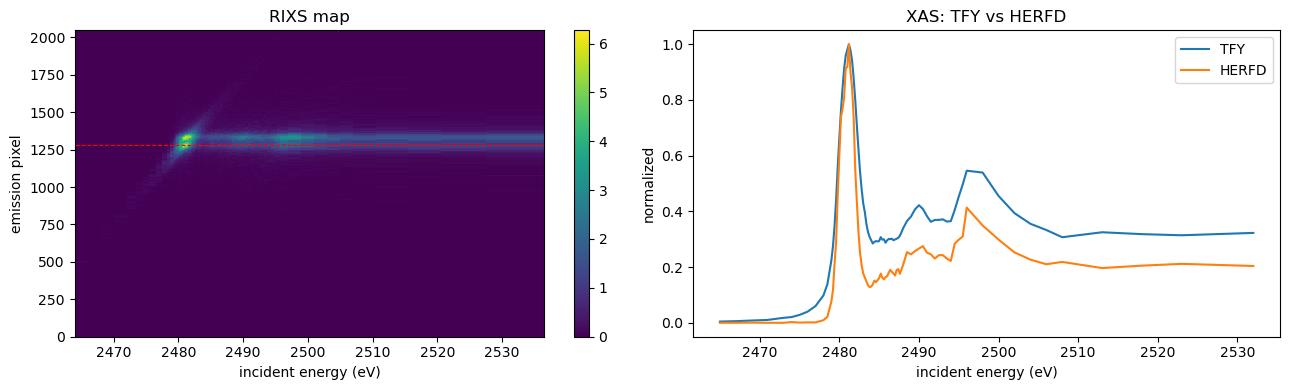

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

im = ax[0].pcolormesh(out.E, np.arange(out.rixs_map.shape[0]), out.rixs_map, shading='auto')
ax[0].set(title='RIXS map', xlabel='incident energy (eV)', ylabel='emission pixel')
ax[0].axhline(out.central_pix, color='r', lw=0.8, ls='--')
fig.colorbar(im, ax=ax[0])

ax[1].plot(out.E, out.TFY / np.nanmax(out.TFY), label='TFY')
ax[1].plot(out.E, out.HERFD / np.nanmax(out.HERFD), label='HERFD')
ax[1].set(title='XAS: TFY vs HERFD', xlabel='incident energy (eV)', ylabel='normalized'); ax[1].legend()

plt.tight_layout()